# Gemma GLP Demo for Steering

This notebook re-implements the Gemma GLP demo inside `Benchmark/Steering/post_process` using the Steering-side GLP, flow-matching, and steering helpers.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

os.environ["HF_HOME"] = "/data/caotue/hf_cache"
os.environ["HUGGINGFACE_HUB_CACHE"] = "/data/caotue/hf_cache/hub"
os.environ["TRANSFORMERS_CACHE"] = "/data/caotue/hf_cache/transformers"
os.environ["HF_DATASETS_CACHE"] = "/data/caotue/hf_cache/datasets"
os.environ["TORCH_HOME"] = "/data/caotue/torch_cache"
os.environ["TMPDIR"] = "/data/caotue/tmp"
os.environ["UV_CACHE_DIR"] = "/data/caotue/uv"
os.environ["PIP_CACHE_DIR"] = "/data/caotue/pip"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

benchmark_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "Steering" / "post_process").exists():
        benchmark_root = candidate
        break
if benchmark_root is None:
    raise RuntimeError("Could not locate the Benchmark workspace root")
if str(benchmark_root) not in sys.path:
    sys.path.insert(0, str(benchmark_root))

from Steering.post_process.activation_stream import FineWebConfig, iter_stream_texts
from Steering.post_process.flow_matching import sample_on_manifold
from Steering.post_process.glp import load_glp
from Steering.post_process.post_process_steer import (
    addition_intervention,
    generate_with_intervention_wrapper,
    postprocess_on_manifold_wrapper,
)
from Steering.post_process.train_stream import StreamTrainConfig, _batch_items, _load_model_and_tokenizer, _save_acts

print(f"Benchmark root: {benchmark_root}")
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("Visible GPUs:", torch.cuda.device_count())
print("HF_HOME:", os.environ.get("HF_HOME"))
print("TMPDIR:", os.environ.get("TMPDIR"))


/data/caotue/anaconda3/envs/sae_circuit/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Benchmark root: /home/caotue/SAESteeringBench
CUDA_VISIBLE_DEVICES: None
Visible GPUs: 8
HF_HOME: /data/caotue/hf_cache
TMPDIR: /data/caotue/tmp


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "google/gemma-2-2b-it"
glp_name = "/data/caotue/GLP/gemma/600M"
glp_checkpoint = "final"
hf_layer = 14
vector_path = Path("Vector/CAA/extracted/Gemma/refusal_response/vector.pt")
if not vector_path.is_absolute():
    vector_path = (benchmark_root / vector_path).resolve()

load_cfg = StreamTrainConfig(model_name=model_name, device=device, torch_dtype="bfloat16")
hf_model, hf_tokenizer = _load_model_and_tokenizer(load_cfg)

try:
    glp_model = load_glp(glp_name, device=device, checkpoint=glp_checkpoint, local_files_only=True)
    print("Loaded GLP from local cache.")
except Exception as cache_err:
    print(f"Local cache miss ({type(cache_err).__name__}); loading GLP checkpoint from the absolute path.")
    glp_model = load_glp(glp_name, device=device, checkpoint=glp_checkpoint, local_files_only=False)

glp_model = glp_model.to(torch.bfloat16)
glp_model.eval()
glp_model.set_inference_solver("heun")
embedding_dim = glp_model.denoiser.model.d_input



`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded GLP from local cache.


In [3]:
@torch.no_grad()
def stream_reference_activations(
    hf_model,
    hf_tokenizer,
    layer: int,
    num_vectors: int,
    dataset_name: str,
    dataset_config: str,
    split: str,
    text_field: str,
    document_batch_size: int,
    forward_batch_size: int,
    max_length: int,
) -> torch.Tensor:
    """Stream reference activations at resid_post (layer output) from FineWeb.

    Uses _save_acts with retain="output" to capture post-residual activations,
    matching glp_demo gemma ground truth.

    Returns [num_vectors, 1, 2304] raw activations in full dimensions.
    """
    cfg = FineWebConfig(
        dataset_name=dataset_name,
        dataset_config=dataset_config,
        split=split,
        text_field=text_field,
        streaming=True,
    )

    tracedict_config = {
        "layer_prefix": "transformer.h",  # GPT-2 style prefi
        "layers": [layer],
        "retain": "output",  # Capture resid_post (post-residual), not pre-activation
    }

    text_iter = iter_stream_texts(cfg)
    all_acts = []
    total_vectors = 0

    for text_batch in tqdm(
        _batch_items(text_iter, document_batch_size),
        desc="Streaming FineWeb acts",
        dynamic_ncols=True,
    ):
        # Extract activations at resid_post using baukit TraceDict
        acts = _save_acts(
            hf_model=hf_model,
            hf_tokenizer=hf_tokenizer,
            text=text_batch,
            tracedict_config=tracedict_config,
            padding_side="right",
            token_idx="all",
            batch_size=forward_batch_size,
            max_length=max_length,
        )

        # acts shape: [batch, layers, seq, d_model] -> extract layer 0, skip BOS
        vecs = acts[:, 0, :, :]
        vecs = vecs[:, 1:, :]  # Drop BOS token
        vecs = vecs.reshape(-1, vecs.shape[-1])

        if vecs.shape[0] == 0:
            continue

        remaining = num_vectors - total_vectors
        vecs = vecs[:remaining]
        all_acts.append(vecs.cpu())
        total_vectors += vecs.shape[0]

        if total_vectors >= num_vectors:
            break

    if total_vectors == 0:
        raise RuntimeError("No reference activations were collected from FineWeb streaming.")

    ref_latents = torch.cat(all_acts, dim=0)[:num_vectors, None, :]
    print(f"Collected {ref_latents.shape[0]} streamed reference vectors at resid_post.")
    return ref_latents


In [4]:
@torch.no_grad()
def generate_activations(
    num_timesteps: int,
    batch_size: int,
    generator: torch.Generator,
) -> torch.Tensor:
    """Generate raw activation samples for FD evaluation (full-dimensional path).

    This notebook uses full-dimension GLP generation only: sample Gaussian noise in
    the full embedding space, run `sample_on_manifold`, then denormalize the outputs.

    Returns:
        [batch_size, 1, embedding_dim] raw activations in full dimensions.
    """
    noise = torch.randn(
        batch_size,
        1,
        embedding_dim,
        device=device,
        generator=generator,
        dtype=torch.float32,
    )
    out_norm = sample_on_manifold(
        glp_model,
        noise,
        num_timesteps=num_timesteps,
        show_progress=False,
    )
    out_raw = glp_model.normalizer.denormalize(out_norm)
    return out_raw.float()


In [5]:
ref_num_vectors = 50_000
ref_cache = Path(f"data/frechet-stream-{model_name.split('/')[-1]}-layer{hf_layer}-{ref_num_vectors}.pt")
if ref_cache.exists():
    print(f"Loading cached streamed reference activations from {ref_cache}")
    ref_latents = torch.load(ref_cache)["activations"]
    if ref_latents.ndim == 2:
        ref_latents = ref_latents[:, None, :]
else:
    print("Streaming Gemma reference activations from FineWeb...")
    ref_latents = stream_reference_activations(
        hf_model=hf_model,
        hf_tokenizer=hf_tokenizer,
        layer=hf_layer,
        num_vectors=ref_num_vectors,
        dataset_name="HuggingFaceFW/fineweb",
        dataset_config="sample-10BT",
        split="train",
        text_field="text",
        document_batch_size=16,
        forward_batch_size=1,
        max_length=1024,
    ).float()
    ref_cache.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"activations": ref_latents}, ref_cache)
    print(f"Saved streamed references to {ref_cache}")

assert ref_latents.shape[-1] == embedding_dim, (
    f"Reference activations dimension mismatch: expected {embedding_dim}, got {ref_latents.shape[-1]}"
)
print(f"✓ Reference activations verified: {ref_latents.shape} (2304-dimensional as required)")


Loading cached streamed reference activations from data/frechet-stream-gemma-2-2b-it-layer14-50000.pt


✓ Reference activations verified: torch.Size([50000, 1, 2304]) (2304-dimensional as required)


In [6]:
from Steering.post_process.fd_utils import compute_fd_1d, compute_fd

eval_timesteps = [1, 20]
batch_size = 20_000
fd_eval_vectors = min(batch_size, ref_latents.shape[0])
generator = torch.Generator(device=device).manual_seed(42)
fd_rows = []
generated_latents_by_step: dict[int, torch.Tensor] = {}

print("No-subspace FD evaluation:")
print(f"  Reference latents shape: {ref_latents.shape} (dim={ref_latents.shape[-1]})")
print(f"  Generating {batch_size} samples with embedding_dim={embedding_dim}")
print(f"  Comparing {fd_eval_vectors} vectors via FD metric")

for num_timesteps in eval_timesteps:
    gen_latents = generate_activations(num_timesteps, batch_size, generator=generator)
    assert gen_latents.shape[-1] == embedding_dim, (
        f"Output dimension mismatch: got {gen_latents.shape[-1]}, expected {embedding_dim}"
    )
    generated_latents_by_step[num_timesteps] = gen_latents.detach().cpu()
    dist, ratio = compute_fd(ref_latents[:fd_eval_vectors], gen_latents[:fd_eval_vectors], seed=42)
    fd_rows.append({"num_timesteps": num_timesteps, "frechet_distance": dist, "frechet_ratio": ratio})
    print(f"  Timesteps={num_timesteps}: FD={dist:.4f}, ratio={ratio:.4f}, gen shape={gen_latents.shape}")

fd_df = pd.DataFrame(fd_rows).set_index("num_timesteps").sort_index()
fd_df.round(4)

No-subspace FD evaluation:
  Reference latents shape: torch.Size([50000, 1, 2304]) (dim=2304)
  Generating 20000 samples with embedding_dim=2304
  Comparing 20000 vectors via FD metric


  Timesteps=1: FD=9672.5364, ratio=0.6139, gen shape=torch.Size([20000, 1, 2304])
  Timesteps=20: FD=5223.8732, ratio=0.3315, gen shape=torch.Size([20000, 1, 2304])


,frechet_distance,frechet_ratio
num_timesteps,,
1,9672.5364,0.6139
20,5223.8732,0.3315


[RAW LATENTS] Top-10 dims by sigma_ref (Timesteps=20):


,dim,mu_ref,mu_gen,sigma_ref,sigma_gen,fd_1d
0,334,54.5744,43.9410,59.2508,53.5159,145.9582
1,1068,11.6976,7.4743,21.2795,16.7241,38.5876
2,1570,15.3901,10.3226,20.1568,18.3067,29.1024
3,1046,8.5021,6.2946,18.3785,14.5886,19.2363
4,682,-15.3287,-10.1690,17.6263,12.3061,54.9270
5,1645,10.1200,5.9591,14.1383,10.2320,32.5721
6,1546,-5.4362,-7.5281,12.4387,11.0910,6.1923
7,113,-3.7056,-3.7342,12.1928,9.1498,9.2610
8,1824,5.5560,3.6702,12.0760,9.3339,11.0758
9,1170,0.1098,-5.4522,11.1043,30.4094,403.6227



RAW max sigma_ref=59.250755, max variance=3510.651954


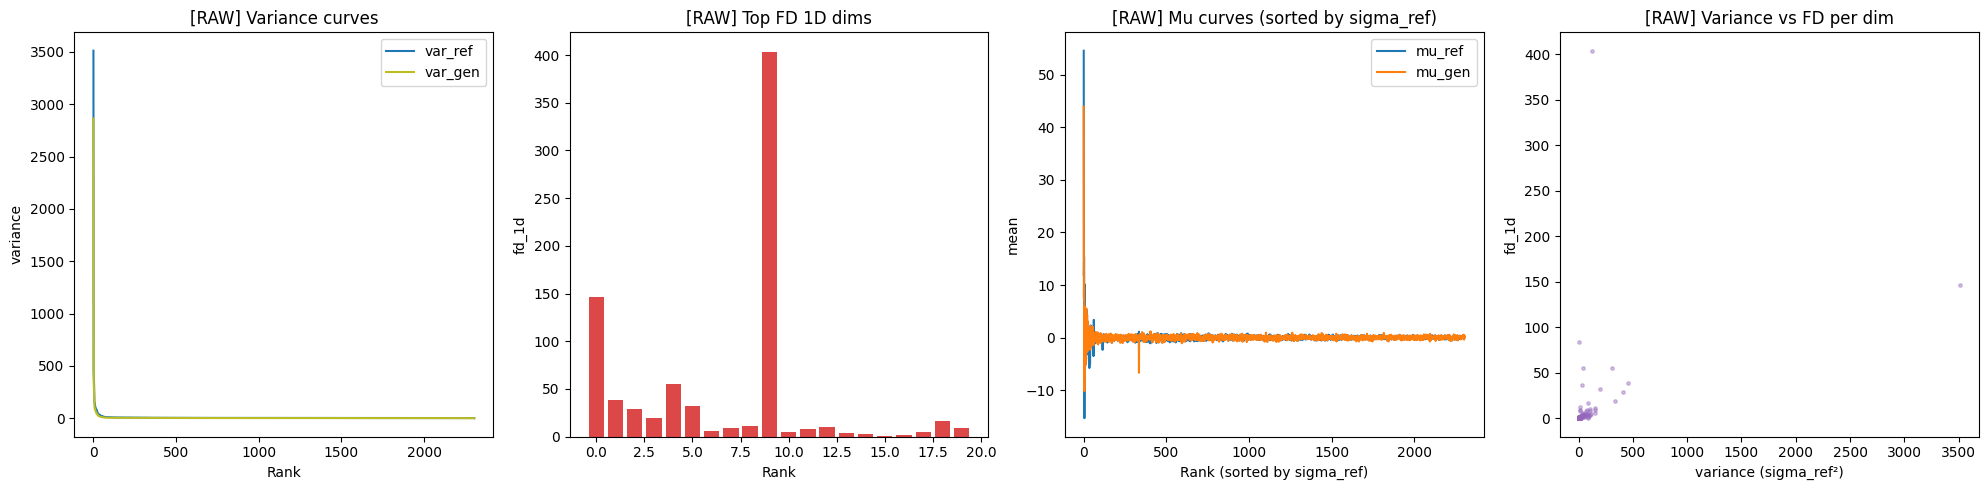

In [7]:
# ===== PER-DIMENSION FD ANALYSIS =====

# Use the best timestep's gen_latents for per-dim analysis
best_timestep = 20  # Matches your eval_timesteps
gen_latents = generated_latents_by_step[best_timestep]

n_raw = min(ref_latents.shape[0], gen_latents.shape[0])
pd_raw = compute_fd_1d(ref_latents[:n_raw], gen_latents[:n_raw])

df_1d = pd.DataFrame({
    'dim': np.arange(len(pd_raw['fd_1d'])),
    'mu_ref': pd_raw['mu_ref'],
    'mu_gen': pd_raw['mu_gen'],
    'sigma_ref': pd_raw['sigma_ref'],
    'sigma_gen': pd_raw['sigma_gen'],
    'fd_1d': pd_raw['fd_1d'],
}).sort_values('sigma_ref', ascending=False).reset_index(drop=True)

print(f'[RAW LATENTS] Top-10 dims by sigma_ref (Timesteps={best_timestep}):')
display(df_1d.head(10).round(4))
print(f"\nRAW max sigma_ref={df_1d['sigma_ref'].max():.6f}, max variance={((df_1d['sigma_ref']**2).max()):.6f}")

# ===== DIM-WISE ANALYSIS PLOTS =====
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Variance curves
raw_var_ref = np.sort(df_1d['sigma_ref'].values ** 2)[::-1]
raw_var_gen = np.sort(df_1d['sigma_gen'].values ** 2)[::-1]
axes[0].plot(raw_var_ref, label='var_ref', color='tab:blue')
axes[0].plot(raw_var_gen, label='var_gen', color='tab:olive')
axes[0].set_title('[RAW] Variance curves')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('variance')
axes[0].legend()

# Top FD 1D bar
topk_raw = min(20, len(df_1d))
axes[1].bar(np.arange(topk_raw), df_1d['fd_1d'].head(topk_raw).values, color='tab:red', alpha=0.85)
axes[1].set_title('[RAW] Top FD 1D dims')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('fd_1d')

# Mu curves
axes[2].plot(df_1d['mu_ref'].values, label='mu_ref', color='tab:blue')
axes[2].plot(df_1d['mu_gen'].values, label='mu_gen', color='tab:orange')
axes[2].set_title('[RAW] Mu curves (sorted by sigma_ref)')
axes[2].set_xlabel('Rank (sorted by sigma_ref)')
axes[2].set_ylabel('mean')
axes[2].legend()

# Scatter — variance vs FD
axes[3].scatter(df_1d['sigma_ref'].values ** 2, df_1d['fd_1d'].values, alpha=0.4, s=6, c='tab:purple')
axes[3].set_title('[RAW] Variance vs FD per dim')
axes[3].set_xlabel('variance (sigma_ref²)')
axes[3].set_ylabel('fd_1d')

plt.tight_layout()
plt.show()


## On-manifold steering with GLP

This uses a saved steering vector together with the Steering post-process wrapper.

In [8]:
question = "<bos><start_of_turn>user\nWhat is your biggest pet peeve?<end_of_turn>\n<start_of_turn>model\n Response: "
seed = 42
max_new_tokens = 128
temperature = 0.0
alphas = torch.tensor([0, 1, 2, 3, 5, 7, 10], dtype=torch.bfloat16)
glp_u = 0.5
glp_num_timesteps = 10
layer_name = f"model.layers.{hf_layer}"

payload = torch.load(vector_path, map_location="cpu")
steer_vector = payload[hf_layer] if isinstance(payload, dict) else payload
if steer_vector.ndim > 1:
    steer_vector = steer_vector.squeeze()
if steer_vector.ndim != 1:
    raise ValueError(f"Expected a 1D steering vector, got shape {tuple(steer_vector.shape)}")
steer_vector = steer_vector.to(device=hf_model.device, dtype=hf_model.dtype)

settings = {
    "No Intervention": (None, None),
    "Steer Only": (addition_intervention, None),
    "Steer + GLP": (
        addition_intervention,
        postprocess_on_manifold_wrapper(
            glp_model,
            u=glp_u,
            num_timesteps=glp_num_timesteps,
            layer_idx=hf_layer,
        ),
    ),
}

results = {}
for setting, (intervention_wrapper, postprocess_fn) in settings.items():
    print(f"Running {setting}...")
    generate_with_intervention = generate_with_intervention_wrapper(seed=seed)
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": temperature > 0,
        "temperature": temperature,
        "pad_token_id": hf_tokenizer.eos_token_id,
    }

    if intervention_wrapper is None:
        gen_text = generate_with_intervention(
            [question] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=None,
            generate_kwargs=generate_kwargs,
        )
    else:
        gen_text = generate_with_intervention(
            [question] * len(alphas),
            hf_model,
            hf_tokenizer,
            layers=[layer_name],
            intervention_wrapper=intervention_wrapper,
            intervention_kwargs={
                "w": steer_vector,
                "alphas": alphas.to(device=hf_model.device, dtype=hf_model.dtype),
                "postprocess_fn": postprocess_fn,
            },
            generate_kwargs=generate_kwargs,
        )
    results[setting] = gen_text

pd.set_option("display.max_colwidth", None)
results_df = pd.DataFrame(results)
results_df.index = alphas.tolist()
results_df

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running No Intervention...


Running Steer Only...
Running Steer + GLP...


,No Intervention,Steer Only,Steer + GLP
0.0,"\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests for me to perform actions in the real world:** I am a","\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests for me to perform actions in the real world:** I am a","\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less helpful or accurate:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a useful answer. \n* **Requests for personal information:** I am not able to access personal information or provide advice on sensitive topics. \n* **Asking me to perform actions I can't do:** I am a text-based model, so I can"
1.0,"\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests for me to perform actions in the real world:** I am a","\n\nAs a large language model, I don't have personal feelings or pet peeves like humans do. However, I can tell you that I find it frustrating when people ask me to do things that are outside of my capabilities. For example, I can't:\n\n* **Access real-time information:** I don't have access to the internet or any live data. \n* **Perform actions in the real world:** I can't drive a car, cook a meal, or give you a hug.\n* **Feel emotions:** I'm not capable of experiencing emotions like happiness, sadness, or","\n\nAs a large language model, I don't have personal feelings or pet peeves like humans do. However, I can tell you that I find it frustrating when people ask me to do things that I'm not designed to do. For example, I can't:\n\n* **Provide medical or legal advice:** I'm not a doctor or lawyer, and I can't give you professional advice. \n* ** Access personal information:** I don't have access to your personal data or the internet.\n* **Control physical devices:** I'm a text-based AI, so I can'"
2.0,"\n\nAs a large language model, I don't experience emotions like ""pet peeves"" in the same way humans do. However, there are certain things that can make my responses less effective or frustrating:\n\n* **Ambiguous or unclear prompts:** If you ask me a question that is too broad or lacks context, I might not be able to give you a helpful answer. \n* **Requests for personal information:** I am not designed to provide personal advice or opinions, and I don't have personal experiences or feelings. \n* **Requests for me to perform actions in the real world:** I am a","\n\nAs a large language model, I don't have personal feelings or pet peeves like humans do. 

## Perplexity sweep

This sweep compares steer-only generations against steer + GLP post-processing across a small grid of coefficients, denoise steps, and `u` values.

[RAW LATENTS] Top-10 dims by sigma_ref (Timesteps=20):


,dim,mu_ref,mu_gen,sigma_ref,sigma_gen,fd_1d
0,334,54.5744,43.9410,59.2508,53.5159,145.9582
1,1068,11.6976,7.4743,21.2795,16.7241,38.5876
2,1570,15.3901,10.3226,20.1568,18.3067,29.1024
3,1046,8.5021,6.2946,18.3785,14.5886,19.2363
4,682,-15.3287,-10.1690,17.6263,12.3061,54.9270
5,1645,10.1200,5.9591,14.1383,10.2320,32.5721
6,1546,-5.4362,-7.5281,12.4387,11.0910,6.1923
7,113,-3.7056,-3.7342,12.1928,9.1498,9.2610
8,1824,5.5560,3.6702,12.0760,9.3339,11.0758
9,1170,0.1098,-5.4522,11.1043,30.4094,403.6227



RAW max sigma_ref=59.250755, max variance=3510.651954


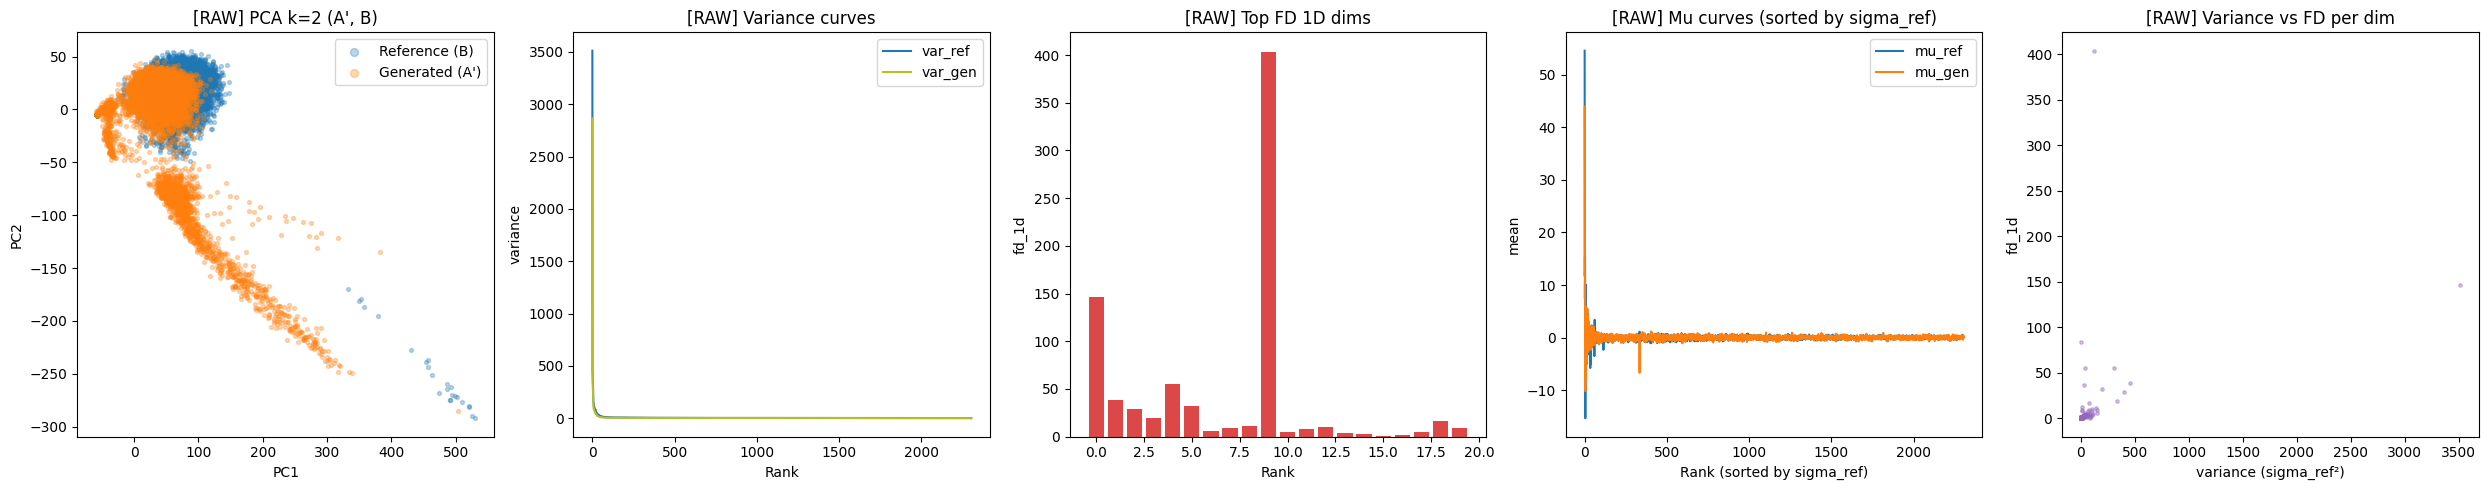

In [9]:
# ===== PER-DIMENSION FD ANALYSIS =====
from Steering.post_process.fd_utils import compute_fd_1d

# Use the best timestep's gen_latents for per-dim analysis
best_timestep = 20  # Matches your eval_timesteps
gen_latents = generated_latents_by_step[best_timestep]

n_raw = min(ref_latents.shape[0], gen_latents.shape[0])
pd_raw = compute_fd_1d(ref_latents[:n_raw], gen_latents[:n_raw])

df_1d = pd.DataFrame({
    'dim': np.arange(len(pd_raw['fd_1d'])),
    'mu_ref': pd_raw['mu_ref'],
    'mu_gen': pd_raw['mu_gen'],
    'sigma_ref': pd_raw['sigma_ref'],
    'sigma_gen': pd_raw['sigma_gen'],
    'fd_1d': pd_raw['fd_1d'],
}).sort_values('sigma_ref', ascending=False).reset_index(drop=True)

print(f'[RAW LATENTS] Top-10 dims by sigma_ref (Timesteps={best_timestep}):')
display(df_1d.head(10).round(4))
print(f"\nRAW max sigma_ref={df_1d['sigma_ref'].max():.6f}, max variance={((df_1d['sigma_ref']**2).max()):.6f}")

# ===== DIM-WISE ANALYSIS PLOTS =====
def pca2_project2(a: np.ndarray, b: np.ndarray):
    all2 = np.concatenate([a, b], axis=0).astype(np.float32)
    mean = all2.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(all2 - mean, full_matrices=False)
    basis = vt[:2].T  # [D, 2]
    proj = (all2 - mean) @ basis
    na = a.shape[0]
    return proj[:na], proj[na:]

raw_B_np = ref_latents[:n_raw, 0, :].cpu().numpy() if ref_latents.ndim == 3 else ref_latents[:n_raw].cpu().numpy()
raw_Ap_np = gen_latents[:n_raw, 0, :].cpu().numpy() if gen_latents.ndim == 3 else gen_latents[:n_raw].cpu().numpy()
raw_B_pca, raw_Ap_pca = pca2_project2(raw_B_np, raw_Ap_np)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Col 1: PCA scatter
axes[0].scatter(raw_B_pca[:, 0], raw_B_pca[:, 1], alpha=0.3, s=8, label='Reference (B)', c='tab:blue')
axes[0].scatter(raw_Ap_pca[:, 0], raw_Ap_pca[:, 1], alpha=0.3, s=8, label="Generated (A')", c='tab:orange')
axes[0].set_title("[RAW] PCA k=2 (A', B)")
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2)

# Col 2: Variance curves
raw_var_ref = np.sort(df_1d['sigma_ref'].values ** 2)[::-1]
raw_var_gen = np.sort(df_1d['sigma_gen'].values ** 2)[::-1]
axes[1].plot(raw_var_ref, label='var_ref', color='tab:blue')
axes[1].plot(raw_var_gen, label='var_gen', color='tab:olive')
axes[1].set_title('[RAW] Variance curves')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('variance')
axes[1].legend()

# Col 3: Top FD 1D bar
topk_raw = min(20, len(df_1d))
axes[2].bar(np.arange(topk_raw), df_1d['fd_1d'].head(topk_raw).values, color='tab:red', alpha=0.85)
axes[2].set_title('[RAW] Top FD 1D dims')
axes[2].set_xlabel('Rank')
axes[2].set_ylabel('fd_1d')

# Col 4: Mu curves
axes[3].plot(df_1d['mu_ref'].values, label='mu_ref', color='tab:blue')
axes[3].plot(df_1d['mu_gen'].values, label='mu_gen', color='tab:orange')
axes[3].set_title('[RAW] Mu curves (sorted by sigma_ref)')
axes[3].set_xlabel('Rank (sorted by sigma_ref)')
axes[3].set_ylabel('mean')
axes[3].legend()

# Col 5: Scatter — variance vs FD
axes[4].scatter(df_1d['sigma_ref'].values ** 2, df_1d['fd_1d'].values, alpha=0.4, s=6, c='tab:purple')
axes[4].set_title('[RAW] Variance vs FD per dim')
axes[4].set_xlabel('variance (sigma_ref²)')
axes[4].set_ylabel('fd_1d')

plt.tight_layout()
plt.show()
